In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score

# 1. Read the data
data = pd.read_csv("data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# 2. Clean the data
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
data['TotalCharges'].fillna(data['TotalCharges'].median(), inplace=True)
data.drop('customerID', axis=1, inplace=True)

# 3. Convert text columns to numbers
label = LabelEncoder()
for col in data.columns:
    if data[col].dtype == 'object':
        data[col] = label.fit_transform(data[col])

# 4. Split into features (X) and target (y)
X = data.drop('Churn', axis=1)
y = data['Churn']

# 5. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

# 6. Scale the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 7. Logistic Regression
log_model = LogisticRegression()
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:, 1]

# 8. K-Nearest Neighbors
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)
y_prob_knn = knn_model.predict_proba(X_test)[:, 1]

# 9. Function to show results
def show_results(y_test, y_pred, y_prob, name):
    print(f"\n--- {name} ---")
    print("Accuracy:", round(accuracy_score(y_test, y_pred), 2))
    print("Precision:", round(precision_score(y_test, y_pred), 2))
    print("Recall:", round(recall_score(y_test, y_pred), 2))
    print("F1 Score:", round(f1_score(y_test, y_pred), 2))
    print("ROC-AUC:", round(roc_auc_score(y_test, y_prob), 2))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# 10. Show both model results
show_results(y_test, y_pred_log, y_prob_log, "Logistic Regression")
show_results(y_test, y_pred_knn, y_prob_knn, "K-Nearest Neighbors")


C:\Users\Vineet Tiwari\AppData\Local\Temp\ipykernel_13004\2346445053.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['TotalCharges'].fillna(data['TotalCharges'].median(), inplace=True)



--- Logistic Regression ---
Accuracy: 0.81
Precision: 0.62
Recall: 0.58
F1 Score: 0.6
ROC-AUC: 0.86
Confusion Matrix:
 [[938 123]
 [146 202]]

--- K-Nearest Neighbors ---
Accuracy: 0.76
Precision: 0.51
Recall: 0.55
F1 Score: 0.53
ROC-AUC: 0.79
Confusion Matrix:
 [[879 182]
 [157 191]]


Dataset Shape: (7043, 21)

First 5 rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport Streami

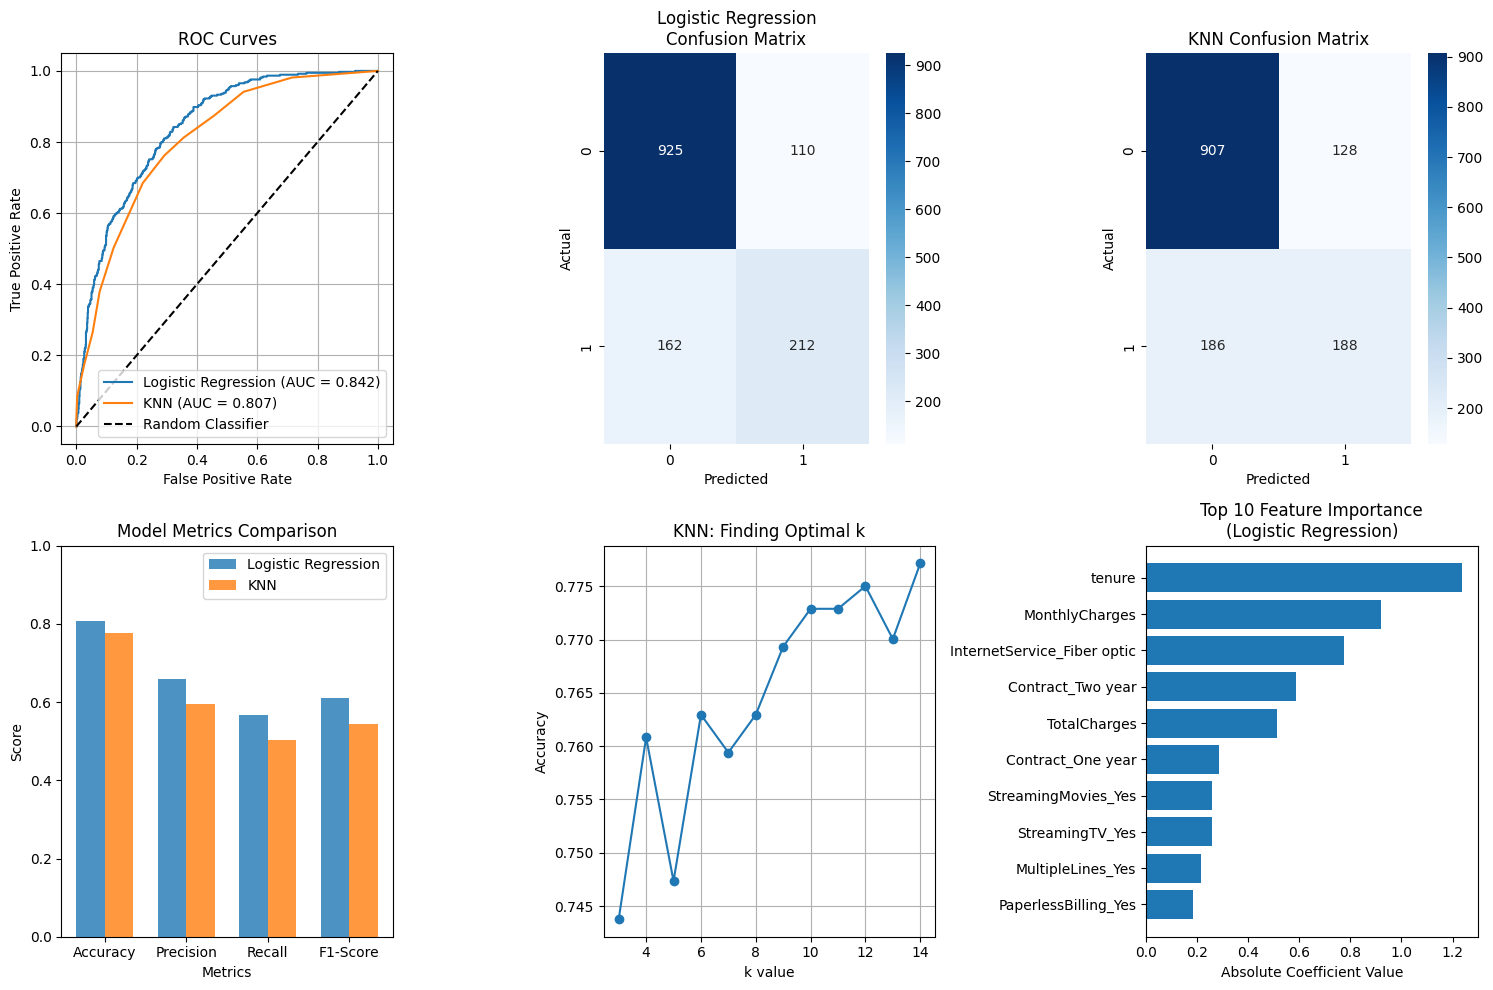


ADDITIONAL ANALYSIS

Class Distribution in Entire Dataset:
Churn: No  - 5174 (73.5%)
Churn: Yes - 1869 (26.5%)

Top 5 Most Important Features (Logistic Regression):
                        feature  coefficient
1                        tenure      -1.2365
2                MonthlyCharges      -0.9202
10  InternetService_Fiber optic       0.7762
25            Contract_Two year      -0.5869
3                  TotalCharges       0.5143

BUSINESS IMPACT ANALYSIS:
If we use Logistic Regression:
- We correctly identify 212 out of 374 churners
- We miss 162 churners who would leave
- We incorrectly flag 110 non-churners as churners

Results saved to 'churn_prediction_results.csv'


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                           confusion_matrix, classification_report, roc_auc_score, roc_curve)
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

# Load your dataset
# Replace 'your_dataset.csv' with your actual file path
df = pd.read_csv('data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Display basic information about the dataset
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())

# Data Preprocessing
print("\n" + "="*50)
print("DATA PREPROCESSING")
print("="*50)

# Handle missing values in TotalCharges (convert to numeric and handle errors)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f"Missing values in TotalCharges: {df['TotalCharges'].isnull().sum()}")

# Fill missing TotalCharges with 0 (for new customers)
df['TotalCharges'].fillna(0, inplace=True)

# Drop customerID as it's not useful for prediction
df = df.drop('customerID', axis=1)

# Convert Churn to binary (0 for No, 1 for Yes)
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

# Identify categorical and numerical columns
categorical_columns = df.select_dtypes(include=['object']).columns
numerical_columns = df.select_dtypes(include=[np.number]).columns.drop('Churn')

print(f"Categorical columns: {list(categorical_columns)}")
print(f"Numerical columns: {list(numerical_columns)}")

# One-hot encoding for categorical variables
df_encoded = pd.get_dummies(df, columns=categorical_columns, drop_first=True)

print(f"Shape after encoding: {df_encoded.shape}")

# Prepare features and target
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Churn rate in training set: {y_train.mean():.3f}")
print(f"Churn rate in test set: {y_test.mean():.3f}")

# Function to evaluate models
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """Comprehensive model evaluation function"""
    
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    
    # Print results
    print(f"\n{model_name} Results:")
    print("="*40)
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"ROC-AUC:   {roc_auc:.4f}")
    
    print("\nConfusion Matrix:")
    print(cm)
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    return {
        'model': model,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'confusion_matrix': cm
    }

# Logistic Regression
print("\n" + "="*50)
print("LOGISTIC REGRESSION")
print("="*50)

log_reg = LogisticRegression(random_state=42, max_iter=1000)
lr_results = evaluate_model(log_reg, X_train_scaled, X_test_scaled, y_train, y_test, "Logistic Regression")

# K-Nearest Neighbors
print("\n" + "="*50)
print("K-NEAREST NEIGHBORS")
print("="*50)

# Find optimal k value
k_range = range(3, 15)
k_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    score = knn.score(X_test_scaled, y_test)
    k_scores.append(score)

optimal_k = k_range[np.argmax(k_scores)]
print(f"Optimal k value: {optimal_k}")

# Train KNN with optimal k
knn = KNeighborsClassifier(n_neighbors=optimal_k)
knn_results = evaluate_model(knn, X_train_scaled, X_test_scaled, y_train, y_test, f"K-Nearest Neighbors (k={optimal_k})")

# Model Comparison
print("\n" + "="*50)
print("MODEL COMPARISON")
print("="*50)

comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', f'KNN (k={optimal_k})'],
    'Accuracy': [lr_results['accuracy'], knn_results['accuracy']],
    'Precision': [lr_results['precision'], knn_results['precision']],
    'Recall': [lr_results['recall'], knn_results['recall']],
    'F1-Score': [lr_results['f1'], knn_results['f1']],
    'ROC-AUC': [lr_results['roc_auc'], knn_results['roc_auc']]
})

print(comparison_df.round(4))

# Visualization
plt.figure(figsize=(15, 10))

# 1. ROC Curve
plt.subplot(2, 3, 1)
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_results['y_pred_proba'])
fpr_knn, tpr_knn, _ = roc_curve(y_test, knn_results['y_pred_proba'])

plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {lr_results["roc_auc"]:.3f})')
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {knn_results["roc_auc"]:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.grid(True)

# 2. Confusion Matrix for Logistic Regression
plt.subplot(2, 3, 2)
sns.heatmap(lr_results['confusion_matrix'], annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression\nConfusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# 3. Confusion Matrix for KNN
plt.subplot(2, 3, 3)
sns.heatmap(knn_results['confusion_matrix'], annot=True, fmt='d', cmap='Blues')
plt.title('KNN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# 4. Metrics Comparison
plt.subplot(2, 3, 4)
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
lr_metrics = [lr_results['accuracy'], lr_results['precision'], lr_results['recall'], lr_results['f1']]
knn_metrics = [knn_results['accuracy'], knn_results['precision'], knn_results['recall'], knn_results['f1']]

x = np.arange(len(metrics))
width = 0.35

plt.bar(x - width/2, lr_metrics, width, label='Logistic Regression', alpha=0.8)
plt.bar(x + width/2, knn_metrics, width, label='KNN', alpha=0.8)
plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Model Metrics Comparison')
plt.xticks(x, metrics)
plt.legend()
plt.ylim(0, 1)

# 5. K-value optimization for KNN
plt.subplot(2, 3, 5)
plt.plot(k_range, k_scores, marker='o')
plt.xlabel('k value')
plt.ylabel('Accuracy')
plt.title('KNN: Finding Optimal k')
plt.grid(True)

# 6. Feature Importance (Logistic Regression)
plt.subplot(2, 3, 6)
if hasattr(log_reg, 'coef_'):
    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': abs(log_reg.coef_[0])
    })
    feature_importance = feature_importance.sort_values('importance', ascending=True).tail(10)
    
    plt.barh(feature_importance['feature'], feature_importance['importance'])
    plt.xlabel('Absolute Coefficient Value')
    plt.title('Top 10 Feature Importance\n(Logistic Regression)')

plt.tight_layout()
plt.show()

# Additional Analysis
print("\n" + "="*50)
print("ADDITIONAL ANALYSIS")
print("="*50)

# Check class distribution
print(f"\nClass Distribution in Entire Dataset:")
print(f"Churn: No  - {len(y[y==0])} ({len(y[y==0])/len(y)*100:.1f}%)")
print(f"Churn: Yes - {len(y[y==1])} ({len(y[y==1])/len(y)*100:.1f}%)")

# Feature analysis for top important features (if available)
if hasattr(log_reg, 'coef_'):
    print(f"\nTop 5 Most Important Features (Logistic Regression):")
    feature_importance_all = pd.DataFrame({
        'feature': X.columns,
        'coefficient': log_reg.coef_[0],
        'abs_importance': abs(log_reg.coef_[0])
    })
    top_features = feature_importance_all.sort_values('abs_importance', ascending=False).head(5)
    print(top_features[['feature', 'coefficient']].round(4))

# Business Impact Analysis
print(f"\nBUSINESS IMPACT ANALYSIS:")
print(f"If we use Logistic Regression:")
print(f"- We correctly identify {lr_results['confusion_matrix'][1,1]} out of {lr_results['confusion_matrix'][1,:].sum()} churners")
print(f"- We miss {lr_results['confusion_matrix'][1,0]} churners who would leave")
print(f"- We incorrectly flag {lr_results['confusion_matrix'][0,1]} non-churners as churners")

# Save results to CSV
results_summary = pd.DataFrame({
    'Model': ['Logistic Regression', f'KNN (k={optimal_k})'],
    'Accuracy': [lr_results['accuracy'], knn_results['accuracy']],
    'Precision': [lr_results['precision'], knn_results['precision']],
    'Recall': [lr_results['recall'], knn_results['recall']],
    'F1_Score': [lr_results['f1'], knn_results['f1']],
    'ROC_AUC': [lr_results['roc_auc'], knn_results['roc_auc']],
    'True_Positives': [lr_results['confusion_matrix'][1,1], knn_results['confusion_matrix'][1,1]],
    'False_Negatives': [lr_results['confusion_matrix'][1,0], knn_results['confusion_matrix'][1,0]]
})

results_summary.to_csv('churn_prediction_results.csv', index=False)
print(f"\nResults saved to 'churn_prediction_results.csv'")